In [179]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import precision_score, recall_score, f1_score


In [180]:
# from google.colab import drive
# drive.mount('/content/drive')
# %cd /content/drive/MyDrive/Studia-II/Uczenie-Maszynowe/Lista7/Zad2

Przykładowe dane (pierwsze 5 wierszy):


,Temperature,Vibration,Speed
0,-7.091268,-0.212262,7.379881
1,5.423618,4.868162,3.059775
2,-11.990429,-3.172308,3.613859
3,8.209309,0.942211,2.445808
4,-6.456550,-5.814733,2.236701


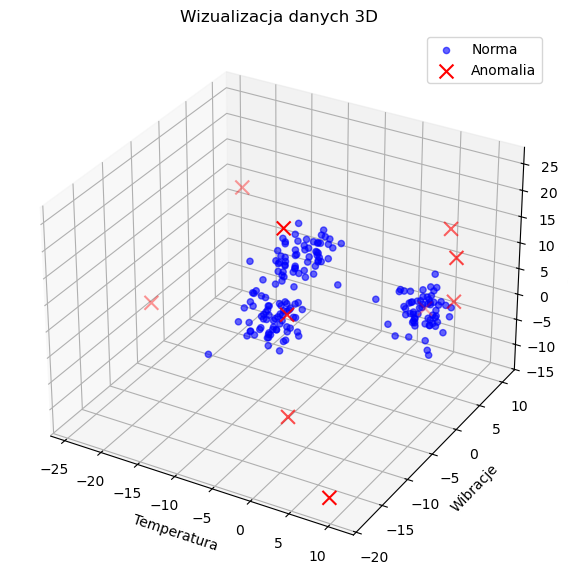

In [181]:
RANDOM_STATE = 2137

np.random.seed(RANDOM_STATE)

n_samples = 200
n_anomalies = 10

centers = 3
n_features = 3
cluster_std = 2.0

X_normal, _ = make_blobs(n_samples=n_samples-n_anomalies, centers=centers, n_features=n_features, cluster_std=cluster_std, random_state=RANDOM_STATE)

center = np.mean(X_normal, axis=0) 

anom_hot = np.random.normal(loc=center, scale=10, size=(4, 3))

anom_vib = np.random.normal(loc=center, scale=10, size=(3, 3))

noise = np.random.uniform(low=-20, high=20, size=(3, 3))
anom_random = center + noise

X_anomalies = np.vstack([anom_hot, anom_vib, anom_random])

X_anomalies = np.vstack([anom_hot, anom_vib, anom_random])

X = np.vstack([X_normal, X_anomalies])

y_true = np.hstack([np.zeros(n_samples - n_anomalies), np.ones(n_anomalies)])

df = pd.DataFrame(X, columns=['Temperature', 'Vibration', 'Speed'])
print("Przykładowe dane (pierwsze 5 wierszy):")
display(df.head())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:n_samples-n_anomalies, 0], X[:n_samples-n_anomalies, 1], X[:n_samples-n_anomalies, 2], c='blue', alpha=0.6, label='Norma')
ax.scatter(X[n_samples-n_anomalies:, 0], X[n_samples-n_anomalies:, 1], X[n_samples-n_anomalies:, 2], c='red', s=100, marker='x', label='Anomalia')

ax.set_xlabel('Temperatura')
ax.set_ylabel('Wibracje')
ax.set_zlabel('Prędkość')
ax.set_title('Wizualizacja danych 3D')
ax.legend()
plt.show()

In [182]:
def print_metrics(y_true, y_pred, method_name):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"--- {method_name} ---")
    print(f"Liczba wykrytych anomalii: {sum(y_pred)}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall:    {recall:.2f}")
    print(f"F1-Score:  {f1:.2f}\n")
    
    return {"Metoda": method_name, "Precision": precision, "Recall": recall, "F1": f1}

results_list = []

In [183]:
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X_scaled)

distances = kmeans.transform(X_scaled).min(axis=1)

threshold = np.percentile(distances, 95)

y_pred_kmeans = (distances > threshold).astype(int)

results_list.append(print_metrics(y_true, y_pred_kmeans, "K-Means"))

--- K-Means ---
Liczba wykrytych anomalii: 10
Precision: 0.90
Recall:    0.90
F1-Score:  0.90



In [184]:

dbscan = DBSCAN(eps=1.2, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

y_pred_dbscan = np.where(labels_dbscan == -1, 1, 0)

results_list.append(print_metrics(y_true, y_pred_dbscan, "DBSCAN"))

--- DBSCAN ---
Liczba wykrytych anomalii: 9
Precision: 1.00
Recall:    0.90
F1-Score:  0.95



In [185]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
labels_lof = lof.fit_predict(X_scaled)

y_pred_lof = np.where(labels_lof == -1, 1, 0)

results_list.append(print_metrics(y_true, y_pred_lof, "LOF"))

--- LOF ---
Liczba wykrytych anomalii: 10
Precision: 0.90
Recall:    0.90
F1-Score:  0.90



,Metoda,Precision,Recall,F1
0,K-Means,0.9,0.9,0.900000
1,DBSCAN,1.0,0.9,0.947368
2,LOF,0.9,0.9,0.900000


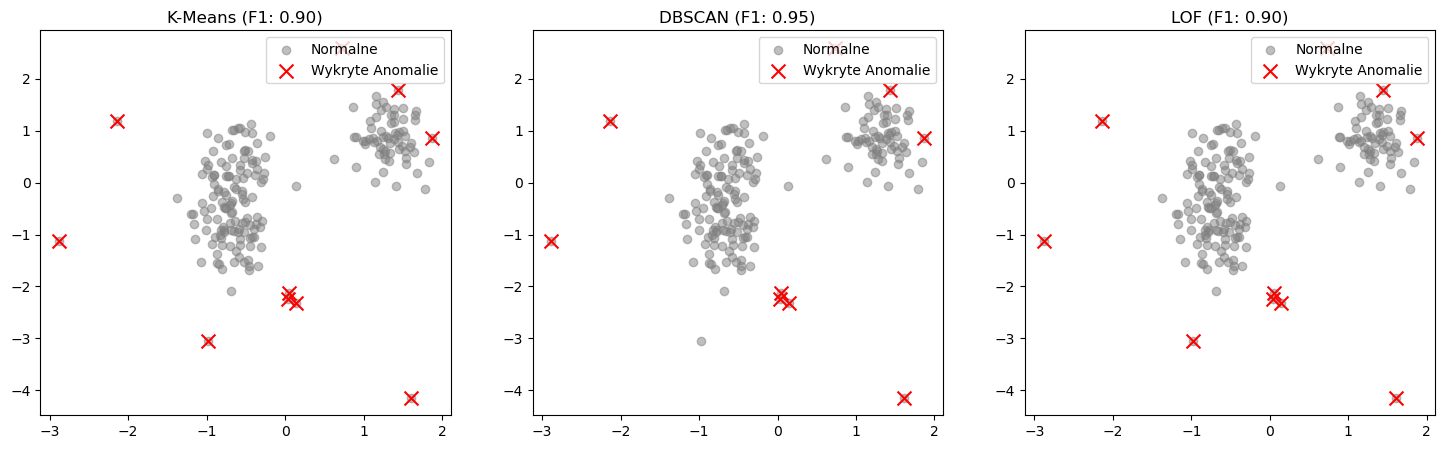

In [186]:
df_results = pd.DataFrame(results_list)

display(df_results)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
methods_preds = [("K-Means", y_pred_kmeans), ("DBSCAN", y_pred_dbscan), ("LOF", y_pred_lof)]

for ax, (name, preds) in zip(axes, methods_preds):
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c='gray', alpha=0.5, label='Normalne')
    
    anomalies = X_scaled[preds == 1]
    ax.scatter(anomalies[:, 0], anomalies[:, 1], c='red', marker='x', s=100, label='Wykryte Anomalie')
    
    ax.set_title(f"{name} (F1: {f1_score(y_true, preds):.2f})")
    ax.legend(loc='upper right')

plt.show()

Tutaj najlepiej radzi sobie DBSCAN. 

Nie zmusza nas do zgadywania, jaki procent floty jest zepsuty, w przeciwieństwie do reszty. Wydaje się to naturalne do wykrywania takich anomalii.